# LVBench · 模型自己找得到那一刻嗎?

**測的是 temporal localization。** LVBench 每題附一段 ground-truth 證據區間
(VideoMME 沒有),所以 agent 自己挑的 crop 窗口可以拿去對答案真正在的地方。

Zero-shot Qwen3-VL-8B,一個工具(`crop_video`:≤128 幀 @1fps 全解析度 temporal crop),
每題最多 5 次呼叫。三個 arm 共用同一套 harness、prompt、64-frame skim 開場,
**只有「誰決定看哪裡」不同** —— 所以差異是定位,不是感知。

| arm | 誰選時間窗 | accuracy (n=183) |
|---|---|---|
| `direct` | 沒有工具 | 31.7% |
| `crop` (autonomous) | **模型自己選** | 33.3% |
| `oracle_crop` | harness 強制對準 GT 證據 | **61.2%** |

**自己選窗口一分沒賺;把窗口對準值 +28pp。**

> 影片中位數長 60 分鐘。全部用現行 parser 重新計分。
> 分析限在 183/200 題 —— 其餘 17 題的
> `time_reference` 解不出合法區間。`oracle_crop` 用 `FA_ORACLE_COT=1`
> (舊版壓掉 CoT,57.0% → 61.5%),天花板應寫成 ~57–62%。


---
## 1 · 看中了多少 · 看中之後值多少

| crop 落點 | n | 佔比 | crop accuracy |
|---|---|---|---|
| 落在證據上 | 39 | 21% | **46.2%** |
| 沒落在證據上 | 98 | 54% | **27.6%** |
| 從未呼叫工具 | 46 | 25% | **34.8%** |
| **全部** | 183 | 100% | 33.3% |

**183 題裡只有 39 題(21%)落在證據上**
(只算有呼叫工具的 137 題也才 28%)。

**落在證據上 46.2%,沒落在 27.6% —— 差 19pp。**
工具是有效的,失敗在「走不到」而不是「看不清」;總分打平是這兩群相消的結果。

> 沒落在證據上的那 98 題,crop 的 27.6% 比 direct 在**同一批題目**上的
> 32.7% 還低 —— 搜錯地方不只是白費,它會把 skim 本來已經答對的題目洗掉。


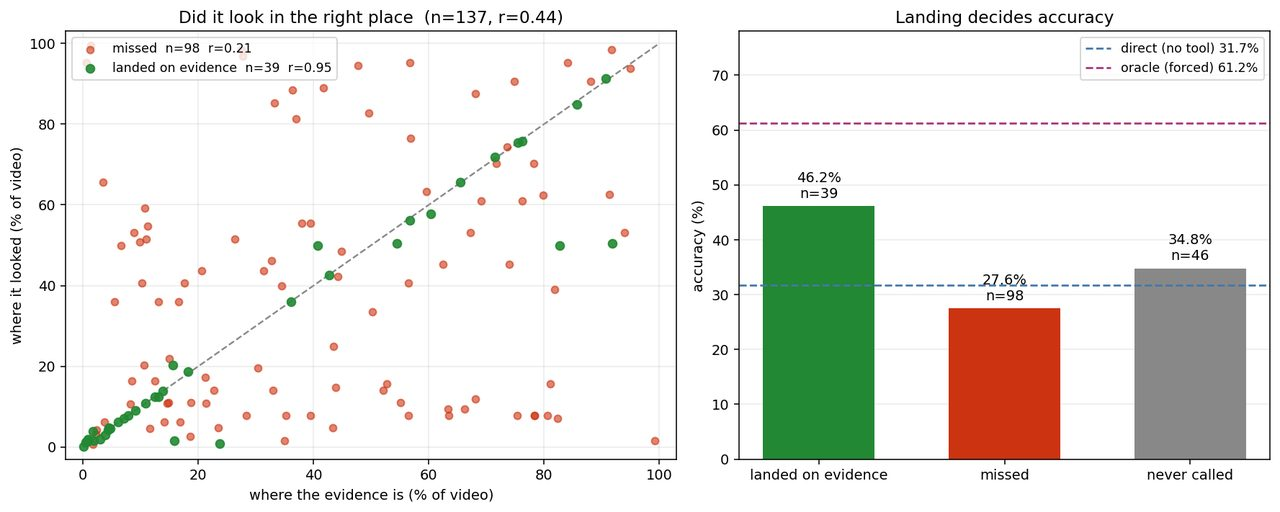

---
## 2 · 它是怎麼搜的

| | 中位數 | p25 – p75 |
|---|---|---|
| crop 窗口寬度 | 54s | 34 – 89s |
| GT 證據寬度 | 14s | 4 – 48s |
| 每題呼叫次數 | 1 | — |
| 整支影片被看過的比例 | **1.6%** | — |

- **寬度是對的,位置是錯的.** 用 54s 的窗口框 14s 的證據是合理邊際 ——
  它知道要多寬,不知道要去哪。
- **它只看過整支影片的 1.6%.** 中位數 60 分鐘的影片、
  中位數 1 次呼叫;5 次 × 54s 在結構上就搜不完一支長片。
- **呼叫次數兩極化.** 46 題一次都不叫、45 題燒滿 5 次,
  中間幾乎是空的。不是「搜到滿意為止」,是「不搜」和「搜到死」。


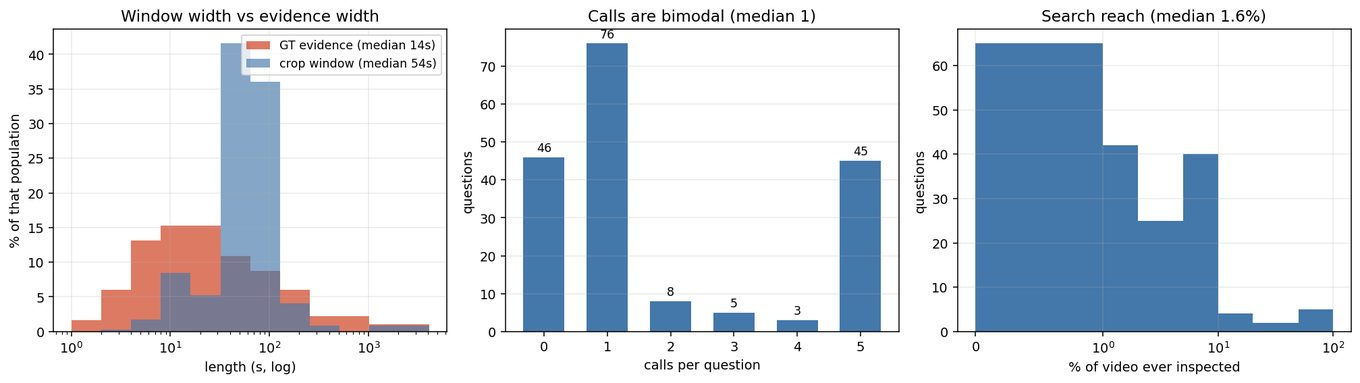

---
## 結論 · 這個模型的 temporal localization 能力

1. **命中率 21%** —— 183 題裡 39 題落在證據上。
2. **但落點不是隨機的.** 全體 r = 0.44;拆開看,命中那群 r = 0.95、
   沒命中那群 r = 0.21。**要嘛它知道在哪(幾乎完美),要嘛它在猜 ——
   中間沒有「差不多對」。** 這是雙峰,不是一條有雜訊的迴歸線。
3. **命中就有回報.** 46.2% vs 27.6%;而強制對準的 oracle 是
   61.2% —— 命中之後它已經取到大部分的值,剩下的差距屬於感知,不屬於定位。
4. **瓶頸是搜尋的觸及範圍.** 只看過影片的 1.6%,而寬度選得合理 ——
   缺的不是解析度、不是預算配置,是**知道要往哪裡去**。

**可訓練的量就是命中率。** Reward 應該直接打在 span 與證據的重疊上、獨立於答案對錯;
46 不叫 / 45 燒滿的兩極分布則指向一條 STOP 規則
(round 0 已覆蓋證據就停)。
